<a href="https://colab.research.google.com/github/Inodb14/Predictive-Analysis-Using-Na-ve-Bayes-Classifier/blob/main/Assignement_Simpore_Inoussa_9230174022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EVALUATION OF PREDICTIVE ANALYSIS
SIMPORE INOUSSA
MBA.BA\
N 92301474022

TOPIC: Make a Feedback Analysis using Naïve Bayes Classifier on a dataset.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:

# Chemin d'accès au fichier CSV
chemin_fichier = '/content/drive/MyDrive/financial_data.csv'

# Lire le fichier CSV avec Pandas
df= pd.read_csv(chemin_fichier)

# Afficher les premières lignes du DataFrame (facultatif)
print(df.head(5))



    Age  Income (k$)  Credit Score  Loan Amount (k$) Employment Status  \
0  56.0         95.0         371.0            1904.0          Employed   
1  41.0         89.0         430.0            1692.0          Employed   
2  39.0         41.0           NaN             910.0         Freelance   
3  20.0         59.0         784.0             352.0        Unemployed   
4  31.0         57.0         639.0             874.0          Employed   

   Debt-to-Income Ratio  Savings (k$)  Number of Credit Accounts  \
0                  0.18           3.7                        8.0   
1                  0.58           6.4                        5.0   
2                  0.22           0.4                        3.0   
3                  0.19           0.6                        2.0   
4                  0.44           8.8                        NaN   

   Loan Term (years) Transaction Type Loan Default  
0               15.0          Deposit           No  
1                1.0          Deposit   

In [7]:
print("\nValeurs manquantes:\n", df.isnull().sum())




Valeurs manquantes:
 Age                          49
Income (k$)                  45
Credit Score                 42
Loan Amount (k$)             51
Employment Status            48
Debt-to-Income Ratio         51
Savings (k$)                 59
Number of Credit Accounts    44
Loan Term (years)            53
Transaction Type             61
Loan Default                 49
dtype: int64


In [ ]:

print("\nTypes de données:\n", df.dtypes)



Types de données:
 Age                          float64
Income (k$)                  float64
Credit Score                 float64
Loan Amount (k$)             float64
Employment Status             object
Debt-to-Income Ratio         float64
Savings (k$)                 float64
Number of Credit Accounts    float64
Loan Term (years)            float64
Transaction Type              object
Loan Default                  object
dtype: object


In [ ]:
print("\nExemples de données:\n", df.sample(3))


Exemples de données:
       Age  Income (k$)  Credit Score  Loan Amount (k$) Employment Status  \
763  28.0         57.0         845.0             406.0          Employed   
716  29.0         89.0         762.0            1492.0     Self-Employed   
54   30.0         56.0         807.0             862.0          Employed   

     Debt-to-Income Ratio  Savings (k$)  Number of Credit Accounts  \
763                  0.21          16.4                        7.0   
716                  0.20           1.4                        4.0   
54                   0.53           7.6                        5.0   

     Loan Term (years) Transaction Type Loan Default  
763               15.0       Investment           No  
716               10.0              NaN           No  
54                20.0       Investment           No  


In [ ]:
# 3. Nettoyage des données
# Gestion des valeurs manquantes
df['Credit Score'] = df['Credit Score'].fillna(df['Credit Score'].median())


In [ ]:
df.head(10)

,Age,Income (k$),Credit Score,Loan Amount (k$),Employment Status,Debt-to-Income Ratio,Savings (k$),Number of Credit Accounts,Loan Term (years),Transaction Type,Loan Default
0,56.0,95.0,371.0,1904.0,Employed,0.18,3.7,8.0,15.0,Deposit,No
1,41.0,89.0,430.0,1692.0,Employed,0.58,6.4,5.0,1.0,Deposit,Yes
2,39.0,41.0,589.5,910.0,Freelance,0.22,0.4,3.0,10.0,Deposit,No
3,20.0,59.0,784.0,352.0,Unemployed,0.19,0.6,2.0,10.0,Investment,No
4,31.0,57.0,639.0,874.0,Employed,0.44,8.8,NaN,20.0,Deposit,No
5,67.0,134.0,589.5,690.0,Employed,0.36,23.4,2.0,3.0,Deposit,NaN
6,27.0,63.0,570.0,597.0,Employed,0.20,6.6,2.0,30.0,Transfer,No
7,43.0,97.0,516.0,200.0,Employed,0.37,9.3,1.0,1.0,Investment,No
8,41.0,58.0,362.0,344.0,Self-Employed,0.45,13.9,NaN,3.0,Deposit,Yes
9,58.0,95.0,327.0,1708.0,Self-Employed,0.41,3.6,7.0,30.0,Deposit,Yes


In [ ]:

df['Income (k$)'] = pd.to_numeric(df['Income (k$)'], errors='coerce').fillna(df['Income (k$)'].mean())

In [ ]:
df.head(10)

,Age,Income (k$),Credit Score,Loan Amount (k$),Employment Status,Debt-to-Income Ratio,Savings (k$),Number of Credit Accounts,Loan Term (years),Transaction Type,Loan Default
0,56.0,95.0,371.0,1904.0,Employed,0.18,3.7,8.0,15.0,Deposit,No
1,41.0,89.0,430.0,1692.0,Employed,0.58,6.4,5.0,1.0,Deposit,Yes
2,39.0,41.0,589.5,910.0,Freelance,0.22,0.4,3.0,10.0,Deposit,No
3,20.0,59.0,784.0,352.0,Unemployed,0.19,0.6,2.0,10.0,Investment,No
4,31.0,57.0,639.0,874.0,Employed,0.44,8.8,NaN,20.0,Deposit,No
5,67.0,134.0,589.5,690.0,Employed,0.36,23.4,2.0,3.0,Deposit,NaN
6,27.0,63.0,570.0,597.0,Employed,0.20,6.6,2.0,30.0,Transfer,No
7,43.0,97.0,516.0,200.0,Employed,0.37,9.3,1.0,1.0,Investment,No
8,41.0,58.0,362.0,344.0,Self-Employed,0.45,13.9,NaN,3.0,Deposit,Yes
9,58.0,95.0,327.0,1708.0,Self-Employed,0.41,3.6,7.0,30.0,Deposit,Yes


In [ ]:
# Correction des incohérences catégorielles
df['Employment Status'] = df['Employment Status'].replace({
    'Freelance': 'Self-Employed',
    'freelance': 'Self-Employed'
})

In [ ]:
df.head(10)

,Age,Income (k$),Credit Score,Loan Amount (k$),Employment Status,Debt-to-Income Ratio,Savings (k$),Number of Credit Accounts,Loan Term (years),Transaction Type,Loan Default
0,56.0,95.0,371.0,1904.0,Employed,0.18,3.7,8.0,15.0,Deposit,No
1,41.0,89.0,430.0,1692.0,Employed,0.58,6.4,5.0,1.0,Deposit,Yes
2,39.0,41.0,589.5,910.0,Self-Employed,0.22,0.4,3.0,10.0,Deposit,No
3,20.0,59.0,784.0,352.0,Unemployed,0.19,0.6,2.0,10.0,Investment,No
4,31.0,57.0,639.0,874.0,Employed,0.44,8.8,NaN,20.0,Deposit,No
5,67.0,134.0,589.5,690.0,Employed,0.36,23.4,2.0,3.0,Deposit,NaN
6,27.0,63.0,570.0,597.0,Employed,0.20,6.6,2.0,30.0,Transfer,No
7,43.0,97.0,516.0,200.0,Employed,0.37,9.3,1.0,1.0,Investment,No
8,41.0,58.0,362.0,344.0,Self-Employed,0.45,13.9,NaN,3.0,Deposit,Yes
9,58.0,95.0,327.0,1708.0,Self-Employed,0.41,3.6,7.0,30.0,Deposit,Yes


In [ ]:

df['Transaction Type'] = df['Transaction Type'].str.capitalize()

In [ ]:
# Suppression des doublons
initial_count = len(df)
df = df.drop_duplicates()
print(f"\nDoublons supprimés: {initial_count - len(df)}")




Doublons supprimés: 0


In [ ]:
# 4. Gestion des outliers
Q1 = df['Loan Amount (k$)'].quantile(0.25)
Q3 = df['Loan Amount (k$)'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['Loan Amount (k$)'] < (Q1 - 1.5 * IQR)) |
          (df['Loan Amount (k$)'] > (Q3 + 1.5 * IQR)))]


In [ ]:
df.head(5)

,Age,Income (k$),Credit Score,Loan Amount (k$),Employment Status,Debt-to-Income Ratio,Savings (k$),Number of Credit Accounts,Loan Term (years),Transaction Type,Loan Default
0,56.0,95.0,371.0,1904.0,Employed,0.18,3.7,8.0,15.0,Deposit,No
1,41.0,89.0,430.0,1692.0,Employed,0.58,6.4,5.0,1.0,Deposit,Yes
2,39.0,41.0,589.5,910.0,Self-Employed,0.22,0.4,3.0,10.0,Deposit,No
3,20.0,59.0,784.0,352.0,Unemployed,0.19,0.6,2.0,10.0,Investment,No
4,31.0,57.0,639.0,874.0,Employed,0.44,8.8,NaN,20.0,Deposit,No


In [8]:
import numpy as np
# 5. Feature Engineering
df['Income_to_Loan_Ratio'] = df['Income (k$)'] / df['Loan Amount (k$)'].replace(0, np.nan) # Replace 0 with NaN to avoid division by zero
df['Risk_Profile'] = pd.cut(df['Credit Score'],
                             bins=[0, 579, 669, 739, 799, 850],
                             labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'])

# Before preprocessing, replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)




In [11]:
 #Impute NaN values (if any) with the median for numerical features
for feature in numerical_features:
    # Instead of inplace=True, directly assign the result
    df[feature] = df[feature].fillna(df[feature].median())

In [9]:
df.head(5)

,Age,Income (k$),Credit Score,Loan Amount (k$),Employment Status,Debt-to-Income Ratio,Savings (k$),Number of Credit Accounts,Loan Term (years),Transaction Type,Loan Default,Income_to_Loan_Ratio,Risk_Profile
0,56.0,95.0,371.0,1904.0,Employed,0.18,3.7,8.0,15.0,Deposit,No,0.049895,Poor
1,41.0,89.0,430.0,1692.0,Employed,0.58,6.4,5.0,1.0,Deposit,Yes,0.052600,Poor
2,39.0,41.0,NaN,910.0,Freelance,0.22,0.4,3.0,10.0,Deposit,No,0.045055,NaN
3,20.0,59.0,784.0,352.0,Unemployed,0.19,0.6,2.0,10.0,Investment,No,0.167614,Very Good
4,31.0,57.0,639.0,874.0,Employed,0.44,8.8,NaN,20.0,Deposit,No,0.065217,Fair


In [1]:

# 6. Préprocessing
# Encodage des variables catégorielles
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler # Import OneHotEncoder and StandardScaler
from sklearn.compose import ColumnTransformer #
categorical_features = ['Employment Status', 'Transaction Type', 'Risk_Profile']
numerical_features = ['Age', 'Income (k$)', 'Credit Score', 'Loan Amount (k$)',
                      'Debt-to-Income Ratio', 'Savings (k$)', 'Number of Credit Accounts',
                      'Loan Term (years)', 'Income_to_Loan_Ratio']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])



In [ ]:
df.head(10)

,Age,Income (k$),Credit Score,Loan Amount (k$),Employment Status,Debt-to-Income Ratio,Savings (k$),Number of Credit Accounts,Loan Term (years),Transaction Type,Loan Default,Income_to_Loan_Ratio,Risk_Profile
0,56.0,95.0,371.0,1904.0,Employed,0.18,3.7,8.0,15.0,Deposit,No,0.049895,Poor
1,41.0,89.0,430.0,1692.0,Employed,0.58,6.4,5.0,1.0,Deposit,Yes,0.052600,Poor
2,39.0,41.0,589.5,910.0,Self-Employed,0.22,0.4,3.0,10.0,Deposit,No,0.045055,Fair
3,20.0,59.0,784.0,352.0,Unemployed,0.19,0.6,2.0,10.0,Investment,No,0.167614,Very Good
4,31.0,57.0,639.0,874.0,Employed,0.44,8.8,5.0,20.0,Deposit,No,0.065217,Fair
5,67.0,134.0,589.5,690.0,Employed,0.36,23.4,2.0,3.0,Deposit,NaN,0.194203,Fair
6,27.0,63.0,570.0,597.0,Employed,0.20,6.6,2.0,30.0,Transfer,No,0.105528,Poor
7,43.0,97.0,516.0,200.0,Employed,0.37,9.3,1.0,1.0,Investment,No,0.485000,Poor
8,41.0,58.0,362.0,344.0,Self-Employed,0.45,13.9,5.0,3.0,Deposit,Yes,0.168605,Poor
9,58.0,95.0,327.0,1708.0,Self-Employed,0.41,3.6,7.0,30.0,Deposit,Yes,0.055621,Poor


In [ ]:
# 7. Préparation pour le modèle
X = preprocessor.fit_transform(df.drop('Loan Default', axis=1))
# Convert 'Loan Default' to numerical, handling potential errors
y = pd.to_numeric(df['Loan Default'].map({'Yes': 1, 'No': 0}), errors='coerce')

# Drop rows with NaN values in the target variable 'y'
X = X[~y.isna()]
y = y.dropna()

# 8. Split des données
# Import the train_test_split function
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

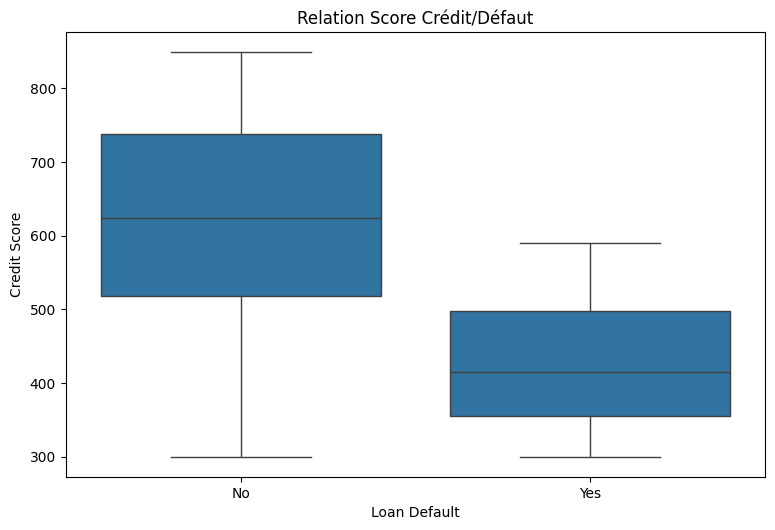

In [ ]:

# 9. Visualisation post-nettoyage
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(x='Loan Default', y='Credit Score', data=df)
plt.title('Relation Score Crédit/Défaut')
plt.tight_layout()
plt.show()


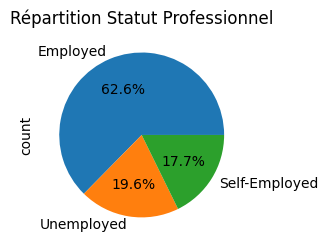

In [ ]:

plt.subplot(2, 2, 2)
df['Employment Status'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Répartition Statut Professionnel')
plt.tight_layout()
plt.show()


(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 [Text(0.5, 0, 'Age'),
  Text(1.5, 0, 'Income (k$)'),
  Text(2.5, 0, 'Credit Score'),
  Text(3.5, 0, 'Loan Amount (k$)'),
  Text(4.5, 0, 'Debt-to-Income Ratio'),
  Text(5.5, 0, 'Savings (k$)'),
  Text(6.5, 0, 'Number of Credit Accounts'),
  Text(7.5, 0, 'Loan Term (years)'),
  Text(8.5, 0, 'Income_to_Loan_Ratio')])

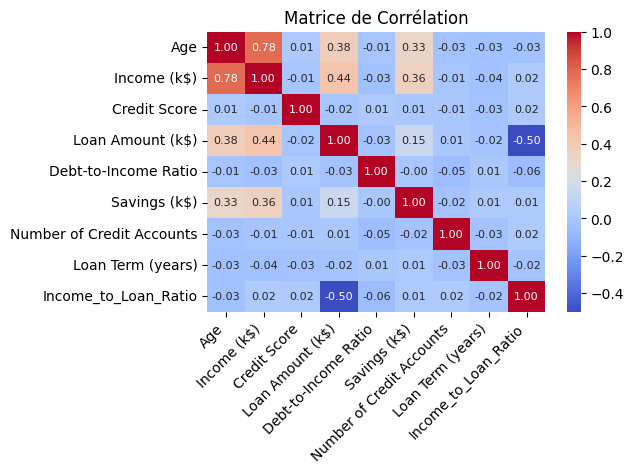

In [ ]:

plt.figure(figsize=(12, 8))  # Increase the overall figure size

# ... your other subplots ...

plt.subplot(2, 2, 3)
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8})
plt.title('Matrice de Corrélation')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')


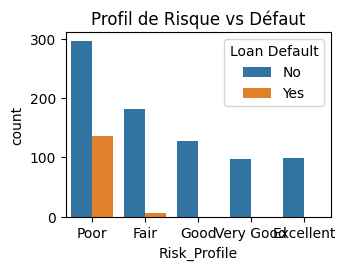

In [ ]:
plt.subplot(2, 2, 4)
sns.countplot(x='Risk_Profile', hue='Loan Default', data=df)
plt.title('Profil de Risque vs Défaut')

plt.tight_layout()
plt.show()

In [ ]:

nltk.download('stopwords')
nltk.download('wordnet')

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove special characters/numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    words = text.split()
    # Remove stopwords
    words = [word for word in words if word not in stopwords.words('english')]
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
print("Valeurs manquantes dans 'Loan Default':", df['Loan Default'].isna().sum())

Valeurs manquantes dans 'Loan Default': 49


In [ ]:
# Supprimer les lignes où 'Loan Default' est manquant
df = df.dropna(subset=['Loan Default'])
print("Valeurs uniques dans 'Loan Default':", df['Loan Default'].unique())

Valeurs uniques dans 'Loan Default': ['No' 'Yes']


In [ ]:
# Après avoir chargé les données (df = pd.read_csv(...))

# Étape Critique: Nettoyer la colonne cible
# -----------------------------------------
# Supprimer les lignes avec Loan Default manquant
df = df.dropna(subset=['Loan Default'])

# Vérifier/corriger les valeurs non conformes (ex: 'yes' -> 'Yes')
df['Loan Default'] = df['Loan Default'].str.strip().str.capitalize()
valid_values = ['Yes', 'No']
df = df[df['Loan Default'].isin(valid_values)]

# Conversion en numérique
y = df['Loan Default'].map({'Yes': 1, 'No': 0})

# Vérification finale
print("Valeurs manquantes après nettoyage:", y.isna().sum())

Valeurs manquantes après nettoyage: 0


In [ ]:
df.head (5)

,Age,Income (k$),Credit Score,Loan Amount (k$),Employment Status,Debt-to-Income Ratio,Savings (k$),Number of Credit Accounts,Loan Term (years),Transaction Type,Loan Default,Income_to_Loan_Ratio,Risk_Profile
0,56.0,95.0,371.0,1904.0,Employed,0.18,3.7,8.0,15.0,Deposit,No,0.049895,Poor
1,41.0,89.0,430.0,1692.0,Employed,0.58,6.4,5.0,1.0,Deposit,Yes,0.052600,Poor
2,39.0,41.0,589.5,910.0,Self-Employed,0.22,0.4,3.0,10.0,Deposit,No,0.045055,Fair
3,20.0,59.0,784.0,352.0,Unemployed,0.19,0.6,2.0,10.0,Investment,No,0.167614,Very Good
4,31.0,57.0,639.0,874.0,Employed,0.44,8.8,5.0,20.0,Deposit,No,0.065217,Fair


In [ ]:
# Assuming 'feedback' should be derived from an existing column, like 'Loan Reason'
# Replace 'Loan Reason' with the actual column name containing feedback if different
#df['cleaned_feedback'] = df['Loan Reason'].apply(preprocess_text)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer  # Import SimpleImputer for handling missing values
from sklearn.pipeline import Pipeline  # Import Pipeline for creating a processing pipeline

# Check/create 'Income_to_Loan_Ratio'
if 'Income_to_Loan_Ratio' not in df.columns:
    df['Income_to_Loan_Ratio'] = df['Income (k$)'] / (df['Loan Amount (k$)'] + 1e-6)  # Adding a small value to avoid division by zero

# Define features
numerical_features = [
    'Age',
    'Income (k$)',
    'Credit Score',
    'Loan Amount (k$)',
    'Debt-to-Income Ratio',
    'Savings (k$)',
    'Number of Credit Accounts',
    'Loan Term (years)',
    'Income_to_Loan_Ratio'
]

categorical_features = [
    'Employment Status',
    'Transaction Type',
    'Risk_Profile'
]

# Transformation pipeline with imputation
# Create pipelines for numerical and categorical features
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Impute missing numerical values with median
    ('scaler', StandardScaler())  # Scale numerical features
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing categorical values with most frequent
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))  # One-hot encode categorical features
])

# Use ColumnTransformer to apply pipelines to different feature types
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ])


# -------------------------------------------------
# 3. Data Preparation
# -------------------------------------------------
X = preprocessor.fit_transform(df.drop('Loan Default', axis=1))
y = df['Loan Default'].map({'Yes': 1, 'No': 0})  # Convert target to numerical

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

# -------------------------------------------------
# 4. Model Training
# -------------------------------------------------
model = GaussianNB()
model.fit(X_train, y_train)

# -------------------------------------------------
# 5. Evaluation and Interpretation
# -------------------------------------------------
y_pred = model.predict(X_test)

print("\n=== Model Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))



=== Model Performance ===
Accuracy: 0.68

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.64      0.77       201
           1       0.31      0.91      0.46        35

    accuracy                           0.68       236
   macro avg       0.64      0.78      0.62       236
weighted avg       0.88      0.68      0.73       236



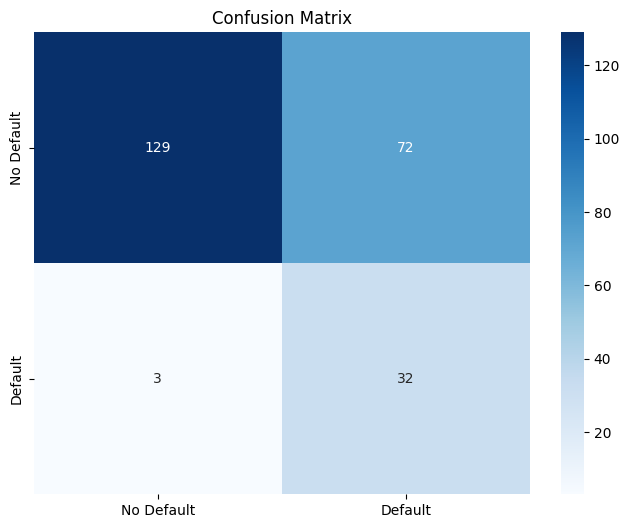


Feature Importance (Standard Deviation of Means):
Credit Score: 0.6185
Debt-to-Income Ratio: 0.6028
Risk_Profile_Poor: 0.2989
Risk_Profile_Fair: 0.0994
Risk_Profile_Good: 0.0760
Risk_Profile_Very Good: 0.0609
Number of Credit Accounts: 0.0486
Savings (k$): 0.0422
Income_to_Loan_Ratio: 0.0345
Loan Term (years): 0.0272


In [ ]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title("Confusion Matrix")
plt.show()

# Feature Importance (for GaussianNB)
print("\nFeature Importance (Standard Deviation of Means):")
# Get feature names after preprocessing
feature_names = numerical_features + list(preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(categorical_features))

importance = np.std(model.theta_, axis=0)
sorted_idx = np.argsort(importance)[::-1]

for idx in sorted_idx[:10]:  # Top 10 features
    print(f"{feature_names[idx]}: {importance[idx]:.4f}")

In [ ]:
# Essayer de combiner Risk_Profile en une variable ordinale
df['Risk_Profile_Score'] = df['Risk_Profile'].map({
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Very Good': 3
})

In [ ]:
# Créer une interaction entre Credit Score et Debt Ratio
df['Risk_Index'] = df['Credit Score'] / (df['Debt-to-Income Ratio'] + 1e-6)

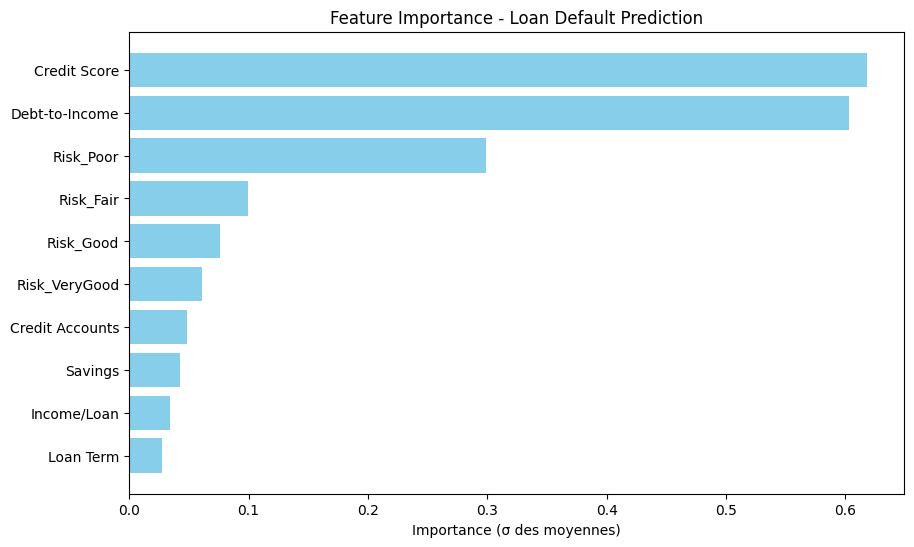

In [ ]:
import matplotlib.pyplot as plt

features = ['Credit Score', 'Debt-to-Income', 'Risk_Poor', 'Risk_Fair', 'Risk_Good', 'Risk_VeryGood', 'Credit Accounts', 'Savings', 'Income/Loan', 'Loan Term']
importance = [0.6185, 0.6028, 0.2989, 0.0994, 0.0760, 0.0609, 0.0486, 0.0422, 0.0345, 0.0272]

plt.figure(figsize=(10,6))
plt.barh(features, importance, color='skyblue')
plt.title('Feature Importance - Loan Default Prediction')
plt.xlabel('Importance (σ des moyennes)')
plt.gca().invert_yaxis()
plt.show()